Running λ=0.9 ...


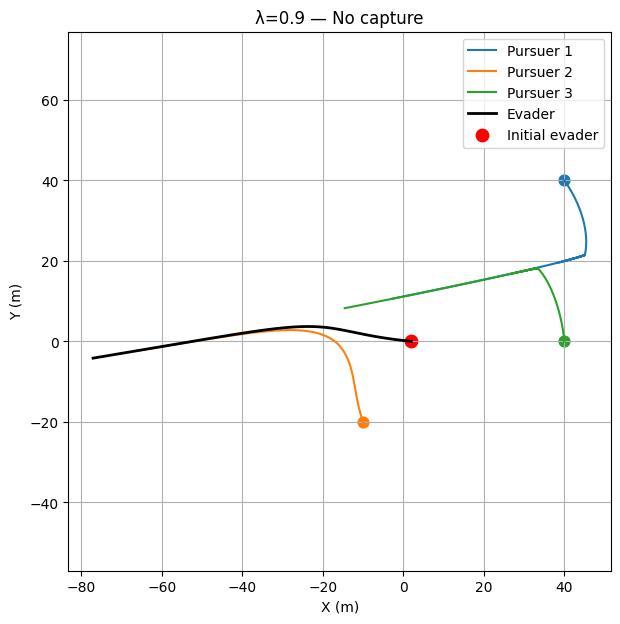

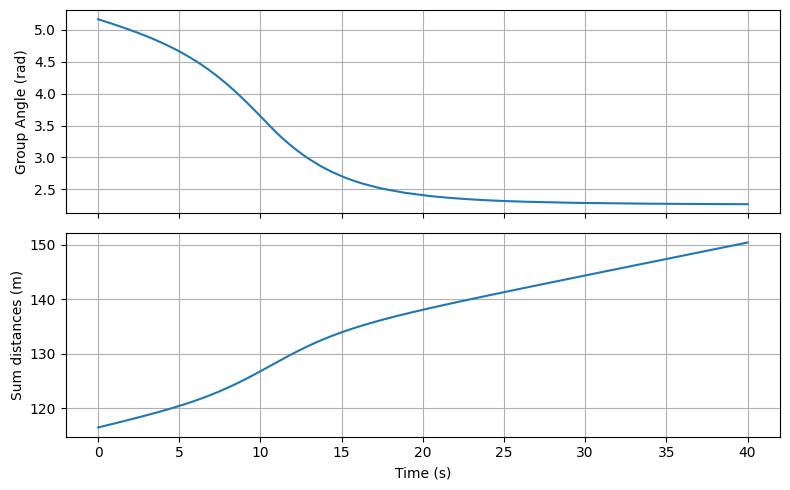

Running λ=0.8 ...


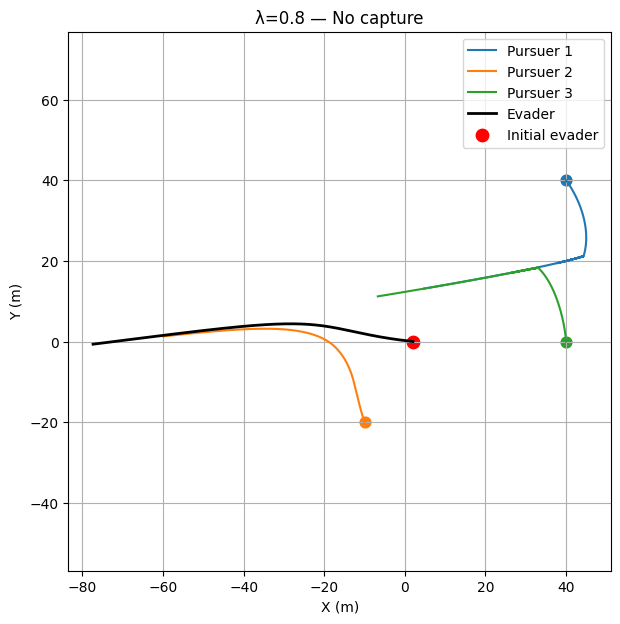

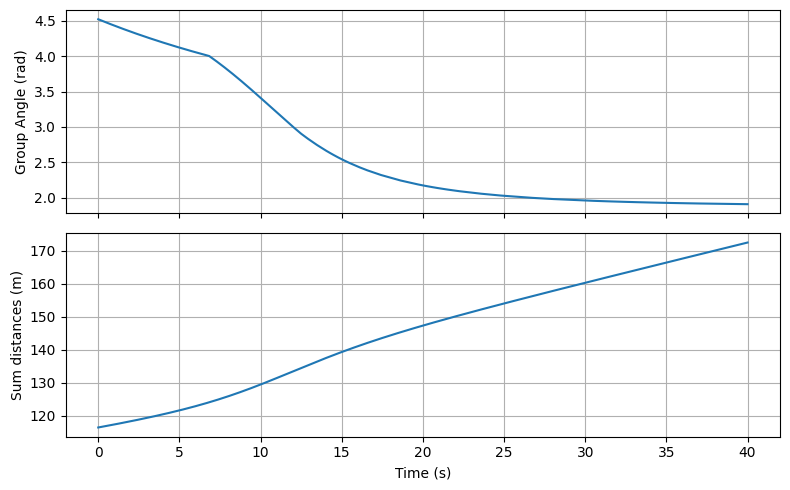

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Default scenario parameters (match paper where possible) ---
Ve = 2.0                       # evader speed (m/s)
ke = 140.0                     # evader gain in Eq.(50)
p_init = np.array([[40.0, 40.0], [-10.0, -20.0], [40.0, 0.0]])  # pursuers initial
evader_init = np.array([2.0, 0.0])
capture_radius = 1.0
dt_default = 0.02
T_default = 40.0


def cooperative_pursuit_capture(lambda_ratio,
                               Ve=Ve,
                               pursuers_init=p_init,
                               evader_init=evader_init,
                               ke=ke,
                               capture_radius=capture_radius,
                               dt=dt_default,
                               Tmax=T_default):
    """
    Single consolidated cooperative pursuit simulation.
    - lambda_ratio: Vi/Ve
    - returns: pursuer_traj (steps+1, n, 2), evader_traj (steps+1, 2), capture_info (dict or None)
    """
    Vi = Ve * lambda_ratio
    pursuers = pursuers_init.astype(float).copy()
    evader = evader_init.astype(float).copy()
    n = len(pursuers)

    traj_p = [pursuers.copy()]
    traj_e = [evader.copy()]

    steps = int(Tmax / dt)
    capture = None

    for step in range(steps):
        # relative vectors (pi - pe)
        rel = pursuers - evader
        ri = np.linalg.norm(rel, axis=1)
        # check capture before updates
        if np.any(ri < capture_radius):
            idx = np.argmin(ri)
            capture = dict(step=step, time=step*dt, pursuer=idx, distance=ri[idx], point=evader.copy())
            break

        # polar angles around evader ([-pi, pi])
        alpha = np.arctan2(rel[:, 1], rel[:, 0])
        # sort CCW (0..2pi) for neighbor calculations
        sort_idx = np.argsort((alpha + 2*np.pi) % (2*np.pi))
        sorted_alpha = alpha[sort_idx]
        sorted_ri = ri[sort_idx]

        # compute angular gaps epsilon for sorted ordering
        eps = np.zeros(n)
        for i in range(n):
            ahead = (i + 1) % n
            behind = (i - 1) % n
            diff = (sorted_alpha[ahead] - sorted_alpha[behind] + np.pi) % (2*np.pi) - np.pi
            eps[i] = diff

        # trade-off between surround (vis) and hunt (vih)
        beta = 0.5 * np.pi * (1 - np.exp(-np.abs(eps)))
        # gains (avoid div-by-zero)
        ki = Vi * np.sin(beta) / (sorted_ri * np.abs(eps) + 1e-8)
        hi = Vi * np.cos(beta) / (sorted_ri + 1e-8)

        # surround (perpendicular) and hunt (radial) components in polar frame
        vis = np.stack([
            -ki * sorted_ri * eps * np.sin(sorted_alpha),
             ki * sorted_ri * eps * np.cos(sorted_alpha)
        ], axis=1)

        vih = np.stack([
            -hi * sorted_ri * np.cos(sorted_alpha),
            -hi * sorted_ri * np.sin(sorted_alpha)
        ], axis=1)

        v_total = vis + vih
        v_norm = np.linalg.norm(v_total, axis=1, keepdims=True) + 1e-10
        pursuers_sorted = pursuers[sort_idx] + Vi * (v_total / v_norm) * dt

        # unsort back to original index order
        new_pursuers = pursuers.copy()
        new_pursuers[sort_idx] = pursuers_sorted
        pursuers = new_pursuers

        # evader update Eq.(50) strong reaction
        dr = evader - pursuers  # (pe - pi)
        ri_ev = np.linalg.norm(dr, axis=1)
        w = (dr.T * ke / (ri_ev + 1e-8)).T  # ke*(pe - pi)/ri
        evec = np.sum(w, axis=0) + evader
        ev_norm = np.linalg.norm(evec)
        if ev_norm > 1e-8:
            ev_dir = evec / ev_norm
            evader = evader + Ve * ev_dir * dt

        traj_p.append(pursuers.copy())
        traj_e.append(evader.copy())

    return np.array(traj_p), np.array(traj_e), capture


def compute_group_metrics(pursuers_hist, evader_hist, lambda_ratio):
    """
    Compute group occupied angle and sum-of-distances time series.
    Uses simple CCW sorting and sum-of-occupied angles with overlaps estimated
    for equal theta_i per pursuer.
    """
    Ve_local = Ve
    Vp = Ve_local * lambda_ratio
    theta_i = 2 * np.arcsin(lambda_ratio)  # occupied angle per pursuer
    times = len(pursuers_hist)
    group_angle = np.zeros(times)
    dist_sum = np.zeros(times)

    for k in range(times):
        purs = pursuers_hist[k]
        pe = evader_hist[k]
        rel = purs - pe
        ri = np.linalg.norm(rel, axis=1)
        alpha = np.arctan2(rel[:, 1], rel[:, 0]) % (2*np.pi)
        idx = np.argsort(alpha)
        # coverage angles between neighbors (CCW)
        eps = []
        for i in range(len(alpha)):
            ai = alpha[idx[i]]
            aj = alpha[idx[(i+1) % len(alpha)]]
            # CCW gap
            gap = (aj - ai) % (2*np.pi)
            # coverage overlap = gap - theta_i (positive gap means no overlap)
            eps.append(gap - theta_i)
        eps = np.array(eps)
        # Group occupied angle = sum theta_i + sum (negative overlaps)
        overlap_neg = np.sum(eps[eps < 0])
        group_angle[k] = len(alpha) * theta_i + overlap_neg
        dist_sum[k] = ri.sum()

    return group_angle, dist_sum


def plot_results(tp, te, capture, lambda_ratio, show_metrics=True):
    fig, ax = plt.subplots(figsize=(7, 7))
    n = tp.shape[1]
    for i in range(n):
        ax.plot(tp[:, i, 0], tp[:, i, 1], label=f'Pursuer {i+1}')
        ax.scatter(tp[0, i, 0], tp[0, i, 1], s=60, marker='o')  # initial
    ax.plot(te[:, 0], te[:, 1], '-k', linewidth=2, label='Evader')
    ax.scatter(te[0, 0], te[0, 1], s=80, color='red', label='Initial evader')

    if capture is not None:
        ax.scatter(capture['point'][0], capture['point'][1], s=150, marker='*', color='red', label='Capture point', zorder=6)
        ax.set_title(f'λ={lambda_ratio} — Capture at t={capture["time"]:.2f}s by P{capture["pursuer"]+1}')
    else:
        ax.set_title(f'λ={lambda_ratio} — No capture')

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.axis('equal')
    ax.grid(True)
    ax.legend()
    plt.show()

    if show_metrics:
        ga, ds = compute_group_metrics(tp, te, lambda_ratio)
        t = np.arange(len(ga)) * dt_default
        fig2, (a1, a2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
        a1.plot(t, ga)
        a1.set_ylabel("Group Angle (rad)")
        a1.grid(True)
        a2.plot(t, ds)
        a2.set_ylabel("Sum distances (m)")
        a2.set_xlabel("Time (s)")
        a2.grid(True)
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    # Runs for lambda=0.9 and 0.8 and plots results
    for lam in (0.9, 0.8):
        print(f"Running λ={lam} ...")
        tp, te, cap = cooperative_pursuit_capture(lambda_ratio=lam, dt=dt_default, Tmax=T_default)
        plot_results(tp, te, cap, lam)

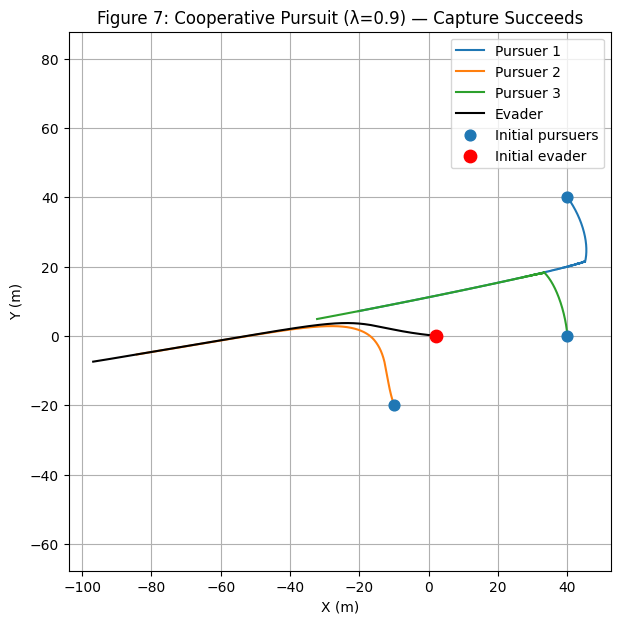

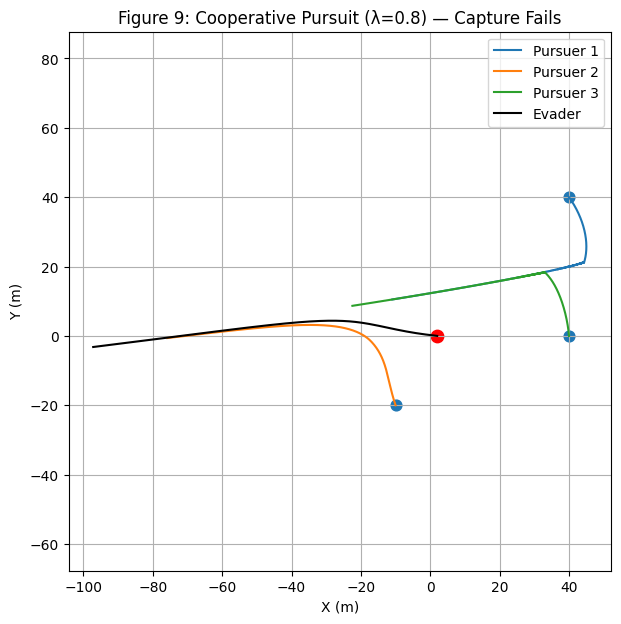

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def cooperative_pursuit_capture(lambda_ratio=0.9, Ve=2, capture_radius=1.0, dt=0.05, max_steps=1000):
    Vi = Ve * lambda_ratio
    pursuers = np.array([[40.0, 40.0], [-10.0, -20.0], [40.0, 0.0]])
    evader = np.array([2.0, 0.0])
    n = len(pursuers)
    traj_p, traj_e = [pursuers.copy()], [evader.copy()]
    ke = 140

    for step in range(max_steps):
        # Compute relative positions, polar angles from evader
        rel = pursuers - evader
        ri = np.linalg.norm(rel, axis=1)
        alpha = np.arctan2(rel[:,1], rel[:,0])
        # Dynamic neighbor ordering by angle
        sort_idx = np.argsort((alpha+2*np.pi) % (2*np.pi))
        sorted_alpha = alpha[sort_idx]
        sorted_ri = ri[sort_idx]
        epsilon = np.zeros(n)
        for i in range(n):
            ahead = (i + 1) % n
            behind = (i - 1) % n
            epsilon[i] = (sorted_alpha[ahead] - sorted_alpha[behind] + np.pi) % (2*np.pi) - np.pi
        # Trade-off
        beta = 0.5*np.pi*(1 - np.exp(-np.abs(epsilon)))
        ki = Vi * np.sin(beta) / (sorted_ri * np.abs(epsilon) + 1e-8)
        hi = Vi * np.cos(beta) / (sorted_ri + 1e-8)
        vis = np.stack([-ki * sorted_ri * epsilon * np.sin(sorted_alpha),
                        ki * sorted_ri * epsilon * np.cos(sorted_alpha)], axis=1)
        vih = np.stack([-hi * sorted_ri * np.cos(sorted_alpha),
                        -hi * sorted_ri * np.sin(sorted_alpha)], axis=1)
        v_total = vis + vih
        v_norm = np.linalg.norm(v_total, axis=1, keepdims=True) + 1e-10
        pursuers_sorted = pursuers[sort_idx] + Vi * v_total / v_norm * dt
        # Unscramble to original order
        pursuers = np.zeros_like(pursuers)
        pursuers[sort_idx] = pursuers_sorted

        # Evader update with strong reaction (Eq. 50)
        dr = evader - pursuers                     # (pe - pi)
        ri = np.linalg.norm(dr, axis=1)            # |pe - pi| = ri
        w = (dr.T * ke / (ri + 1e-8)).T            # ke*(pe - pi)/ri
        evec = np.sum(w, axis=0) + evader          # Σ_i ke*(pe - pi)/ri + pe
        ev_dir = evec / (np.linalg.norm(evec) + 1e-8)  # normalize
        evader += Ve * ev_dir * dt                 # update evader position


        traj_p.append(pursuers.copy())
        traj_e.append(evader.copy())
        # Capture check (stopping condition)
        if np.any(np.linalg.norm(pursuers - evader, axis=1) < capture_radius):
            print(f"Capture at step {step} ({step*dt:.2f} sec)")
            break
    return np.array(traj_p), np.array(traj_e)

# Lambda = 0.9: Should capture
tp, te = cooperative_pursuit_capture(lambda_ratio=0.9)
plt.figure(figsize=(7,7))
for i in range(tp.shape[1]):
    plt.plot(tp[:,i,0], tp[:,i,1], label=f'Pursuer {i+1}')
plt.plot(te[:,0], te[:,1], 'k-', label='Evader')
plt.scatter(tp[0,:,0], tp[0,:,1], s=60, label='Initial pursuers', zorder=5)
plt.scatter(te[0,0], te[0,1], s=80, color='r', label='Initial evader', zorder=5)
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Figure 7: Cooperative Pursuit (λ=0.9) — Capture Succeeds')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

# Lambda = 0.8: Should NOT capture
tp2, te2 = cooperative_pursuit_capture(lambda_ratio=0.8)
plt.figure(figsize=(7,7))
for i in range(tp2.shape[1]):
    plt.plot(tp2[:,i,0], tp2[:,i,1], label=f'Pursuer {i+1}')
plt.plot(te2[:,0], te2[:,1], 'k-', label='Evader')
plt.scatter(tp2[0,:,0], tp2[0,:,1], s=60)
plt.scatter(te2[0,0], te2[0,1], s=80, color='r')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Figure 9: Cooperative Pursuit (λ=0.8) — Capture Fails')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


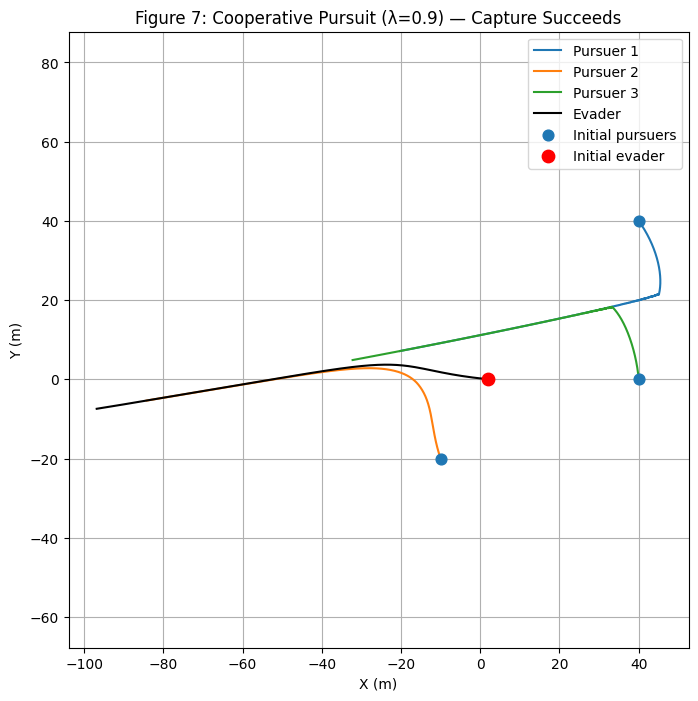

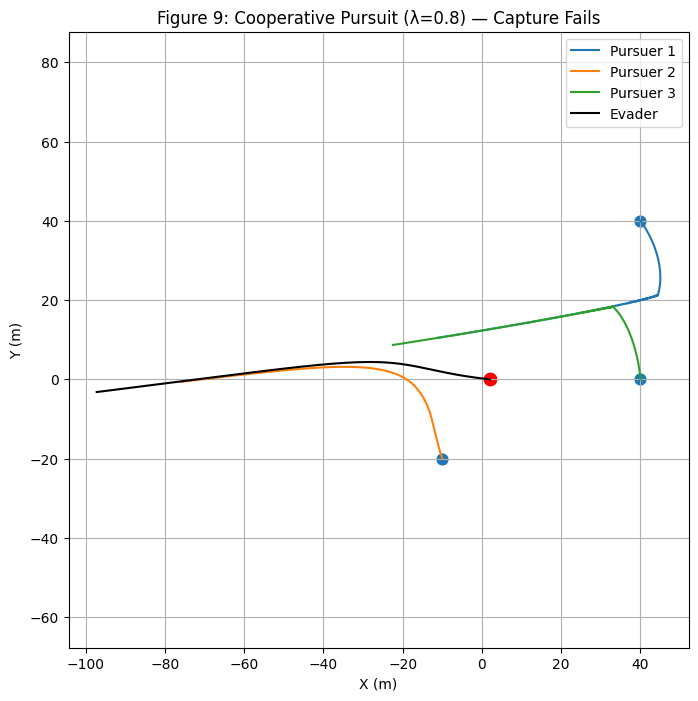

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def cooperative_pursuit_capture(lambda_ratio=0.9, Ve=2, capture_radius=1.0, dt=0.05, max_steps=1000):
    Vi = Ve * lambda_ratio
    pursuers = np.array([[40.0, 40.0], [-10.0, -20.0], [40.0, 0.0]])
    evader = np.array([2.0, 0.0])
    n = len(pursuers)
    traj_p, traj_e = [pursuers.copy()], [evader.copy()]
    ke = 140
    capture_point = None

    for step in range(max_steps):
        # Compute relative positions, polar angles from evader
        rel = pursuers - evader
        ri = np.linalg.norm(rel, axis=1)
        alpha = np.arctan2(rel[:,1], rel[:,0])
        # Dynamic neighbor ordering by angle
        sort_idx = np.argsort((alpha+2*np.pi) % (2*np.pi))
        sorted_alpha = alpha[sort_idx]
        sorted_ri = ri[sort_idx]
        epsilon = np.zeros(n)
        for i in range(n):
            ahead = (i + 1) % n
            behind = (i - 1) % n
            epsilon[i] = (sorted_alpha[ahead] - sorted_alpha[behind] + np.pi) % (2*np.pi) - np.pi
        # Trade-off
        beta = 0.5*np.pi*(1 - np.exp(-np.abs(epsilon)))
        ki = Vi * np.sin(beta) / (sorted_ri * np.abs(epsilon) + 1e-8)
        hi = Vi * np.cos(beta) / (sorted_ri + 1e-8)
        vis = np.stack([-ki * sorted_ri * epsilon * np.sin(sorted_alpha),
                        ki * sorted_ri * epsilon * np.cos(sorted_alpha)], axis=1)
        vih = np.stack([-hi * sorted_ri * np.cos(sorted_alpha),
                        -hi * sorted_ri * np.sin(sorted_alpha)], axis=1)
        v_total = vis + vih
        v_norm = np.linalg.norm(v_total, axis=1, keepdims=True) + 1e-10
        pursuers_sorted = pursuers[sort_idx] + Vi * v_total / v_norm * dt
        # Unscramble to original order
        pursuers = np.zeros_like(pursuers)
        pursuers[sort_idx] = pursuers_sorted

        # Evader update with Eq. (50)
        dr = evader - pursuers
        ri = np.linalg.norm(dr, axis=1)
        w = (dr.T * ke / (ri + 1e-8)).T
        evec = np.sum(w, axis=0) + evader
        ev_dir = evec / (np.linalg.norm(evec) + 1e-8)
        evader += Ve * ev_dir * dt

        traj_p.append(pursuers.copy())
        traj_e.append(evader.copy())

        # Check for capture
        distances = np.linalg.norm(pursuers - evader, axis=1)
        if np.any(distances < capture_radius):
            capture_index = np.argmin(distances)
            capture_point = pursuers[capture_index].copy()
            print(f"Capture by pursuer {capture_index+1} at step={step}, time={step*dt:.2f}s, point={capture_point}")
            break

    return np.array(traj_p), np.array(traj_e), capture_point


# Lambda = 0.9: Should capture
tp, te, cap = cooperative_pursuit_capture(lambda_ratio=0.9)
plt.figure(figsize=(8,8))
for i in range(tp.shape[1]):
    plt.plot(tp[:,i,0], tp[:,i,1], label=f'Pursuer {i+1}')
plt.plot(te[:,0], te[:,1], 'k-', label='Evader')

# Mark starting points
plt.scatter(tp[0,:,0], tp[0,:,1], s=60, label='Initial pursuers', zorder=5)
plt.scatter(te[0,0], te[0,1], s=80, color='r', label='Initial evader', zorder=5)

# Mark capture point if exists
if cap is not None:
    plt.scatter(cap[0], cap[1], s=150, color='red', marker='*', edgecolor='k', label='Capture point', zorder=6)

plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Figure 7: Cooperative Pursuit (λ=0.9) — Capture Succeeds')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


# Lambda = 0.8: Should NOT capture
tp2, te2, cap2 = cooperative_pursuit_capture(lambda_ratio=0.8)
plt.figure(figsize=(8,8))
for i in range(tp2.shape[1]):
    plt.plot(tp2[:,i,0], tp2[:,i,1], label=f'Pursuer {i+1}')
plt.plot(te2[:,0], te2[:,1], 'k-', label='Evader')
plt.scatter(tp2[0,:,0], tp2[0,:,1], s=60)
plt.scatter(te2[0,0], te2[0,1], s=80, color='r')

if cap2 is not None:
    plt.scatter(cap2[0], cap2[1], s=150, color='red', marker='*', edgecolor='k', label='Capture point')

plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Figure 9: Cooperative Pursuit (λ=0.8) — Capture Fails')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


Running λ=0.9 simulation...


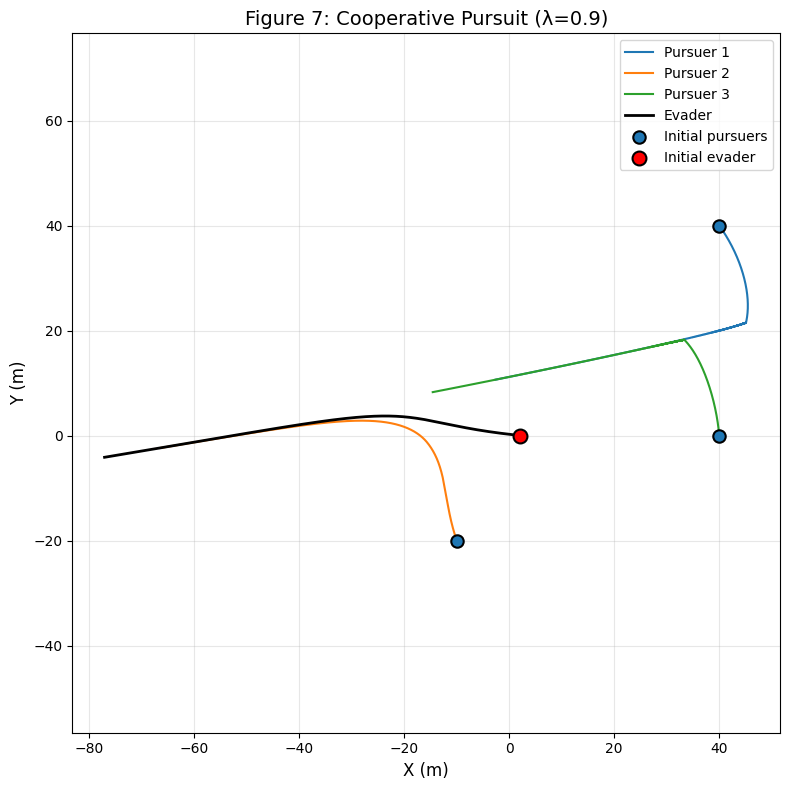


Running λ=0.8 simulation...
Evader successfully escaped (as expected)


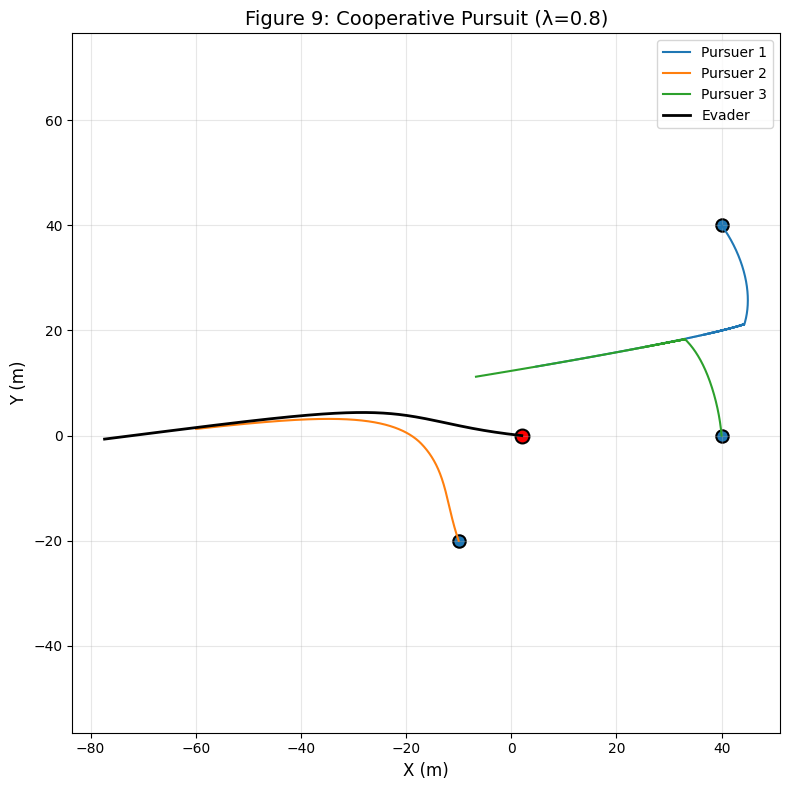

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def cooperative_pursuit_capture(lambda_ratio=0.9, Ve=2, capture_radius=1.0, dt=0.02, max_steps=2000):
    Vi = Ve * lambda_ratio
    pursuers = np.array([[40.0, 40.0], [-10.0, -20.0], [40.0, 0.0]])
    evader = np.array([2.0, 0.0])
    n = len(pursuers)
    traj_p, traj_e = [pursuers.copy()], [evader.copy()]
    ke = 140
    capture_point = None

    for step in range(max_steps):
        # Compute distances
        rel = pursuers - evader
        ri = np.linalg.norm(rel, axis=1)

        # Check capture BEFORE updating
        if np.any(ri < capture_radius):
            capture_index = np.argmin(ri)
            capture_point = evader.copy()  # Capture happens at evader position
            print(f"Capture by pursuer {capture_index+1} at step={step}, time={step*dt:.2f}s")
            print(f"Capture point: {capture_point}")
            print(f"Final distance: {ri[capture_index]:.4f}m")
            break

        # Compute angles
        alpha = np.arctan2(rel[:,1], rel[:,0])
        sort_idx = np.argsort((alpha + 2*np.pi) % (2*np.pi))
        sorted_alpha = alpha[sort_idx]
        sorted_ri = ri[sort_idx]

        # Compute epsilon (angular gaps)
        epsilon = np.zeros(n)
        for i in range(n):
            ahead = (i + 1) % n
            behind = (i - 1) % n
            epsilon[i] = (sorted_alpha[ahead] - sorted_alpha[behind] + np.pi) % (2*np.pi) - np.pi

        # Trade-off angle
        beta = 0.5 * np.pi * (1 - np.exp(-1.0 * np.abs(epsilon)))

        # Gains
        ki = Vi * np.sin(beta) / (sorted_ri * np.abs(epsilon) + 1e-8)
        hi = Vi * np.cos(beta) / (sorted_ri + 1e-8)

        # Velocity components
        vis = np.stack([
            -ki * sorted_ri * epsilon * np.sin(sorted_alpha),
            ki * sorted_ri * epsilon * np.cos(sorted_alpha)
        ], axis=1)

        vih = np.stack([
            -hi * sorted_ri * np.cos(sorted_alpha),
            -hi * sorted_ri * np.sin(sorted_alpha)
        ], axis=1)

        v_total = vis + vih
        v_norm = np.linalg.norm(v_total, axis=1, keepdims=True) + 1e-10

        # Update pursuers (in sorted order)
        pursuers_sorted = pursuers[sort_idx] + Vi * v_total / v_norm * dt
        pursuers[sort_idx] = pursuers_sorted

        # Evader update (Eq. 50)
        dr = evader - pursuers  # (pe - pi)
        ri_evader = np.linalg.norm(dr, axis=1)
        w = (dr.T * ke / (ri_evader + 1e-8)).T
        evec = np.sum(w, axis=0) + evader
        ev_norm = np.linalg.norm(evec)

        if ev_norm > 1e-8:
            ev_dir = evec / ev_norm
            evader += Ve * ev_dir * dt

        traj_p.append(pursuers.copy())
        traj_e.append(evader.copy())

    return np.array(traj_p), np.array(traj_e), capture_point


# Lambda = 0.9: Should capture
print("Running λ=0.9 simulation...")
tp, te, cap = cooperative_pursuit_capture(lambda_ratio=0.9, dt=0.02, max_steps=2000)

plt.figure(figsize=(8,8))
for i in range(tp.shape[1]):
    plt.plot(tp[:,i,0], tp[:,i,1], label=f'Pursuer {i+1}')
plt.plot(te[:,0], te[:,1], 'k-', linewidth=2, label='Evader')

# Mark starting points
plt.scatter(tp[0,:,0], tp[0,:,1], s=80, marker='o', edgecolor='k', linewidth=1.5, label='Initial pursuers', zorder=5)
plt.scatter(te[0,0], te[0,1], s=100, color='red', marker='o', edgecolor='k', linewidth=1.5, label='Initial evader', zorder=5)

# Mark capture point
if cap is not None:
    plt.scatter(cap[0], cap[1], s=200, color='red', marker='*', edgecolor='k', linewidth=2, label='Capture point', zorder=6)
else:
    print("WARNING: No capture occurred!")

plt.xlabel('X (m)', fontsize=12)
plt.ylabel('Y (m)', fontsize=12)
plt.title('Figure 7: Cooperative Pursuit (λ=0.9)', fontsize=14)
plt.legend(fontsize=10)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Lambda = 0.8: Should NOT capture
print("\nRunning λ=0.8 simulation...")
tp2, te2, cap2 = cooperative_pursuit_capture(lambda_ratio=0.8, dt=0.02, max_steps=2000)

plt.figure(figsize=(8,8))
for i in range(tp2.shape[1]):
    plt.plot(tp2[:,i,0], tp2[:,i,1], label=f'Pursuer {i+1}')
plt.plot(te2[:,0], te2[:,1], 'k-', linewidth=2, label='Evader')
plt.scatter(tp2[0,:,0], tp2[0,:,1], s=80, marker='o', edgecolor='k', linewidth=1.5)
plt.scatter(te2[0,0], te2[0,1], s=100, color='red', marker='o', edgecolor='k', linewidth=1.5)

if cap2 is not None:
    plt.scatter(cap2[0], cap2[1], s=200, color='red', marker='*', edgecolor='k', linewidth=2, label='Capture point')
    print("WARNING: Capture occurred at λ=0.8 (should not happen!)")
else:
    print("Evader successfully escaped (as expected)")

plt.xlabel('X (m)', fontsize=12)
plt.ylabel('Y (m)', fontsize=12)
plt.title('Figure 9: Cooperative Pursuit (λ=0.8)', fontsize=14)
plt.legend(fontsize=10)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


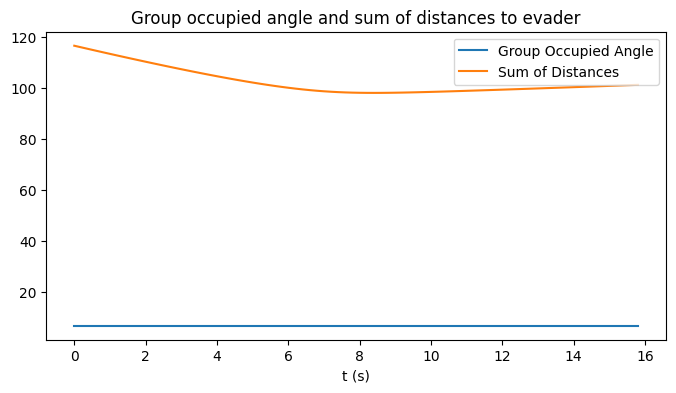

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def group_angle_and_distance():
    Ve = 2
    Vi = 1.8
    pursuers = np.array([[40, 40], [-10, -20], [40, 0]])
    evader = np.array([2, 0])
    n_steps = 80
    dt = 0.2
    group_angle = []
    sum_dist = []
    for t in range(n_steps):
        directions = pursuers - evader
        dists = np.linalg.norm(directions, axis=1)
        lambda_i = Vi / Ve
        theta_i = 2 * np.arcsin(lambda_i)
        group_angle.append(3*theta_i)
        sum_dist.append(dists.sum())
        # Update positions
        norm_dirs = directions / dists[:, None]
        pursuers = pursuers - norm_dirs * Vi * dt
        average_p = pursuers.mean(axis=0)
        evader_dir = evader - average_p
        evader_dir /= np.linalg.norm(evader_dir)
        evader = evader + Ve * evader_dir * dt
    ts = np.arange(n_steps) * dt
    plt.figure(figsize=(8,4))
    plt.plot(ts, group_angle, label="Group Occupied Angle")
    plt.plot(ts, sum_dist, label="Sum of Distances")
    plt.xlabel("t (s)")
    plt.title("Group occupied angle and sum of distances to evader")
    plt.legend()
    plt.show()

group_angle_and_distance()


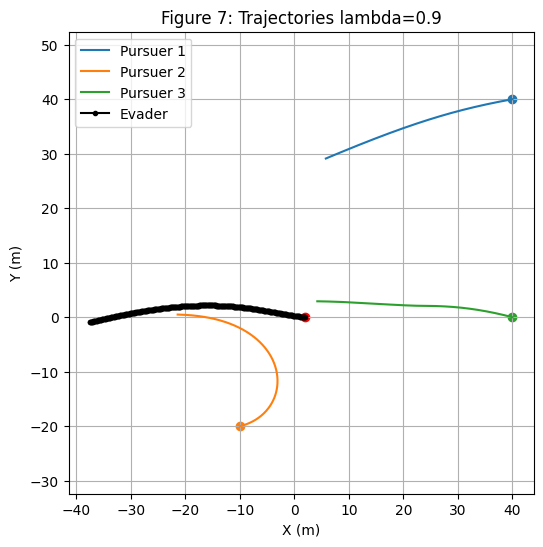

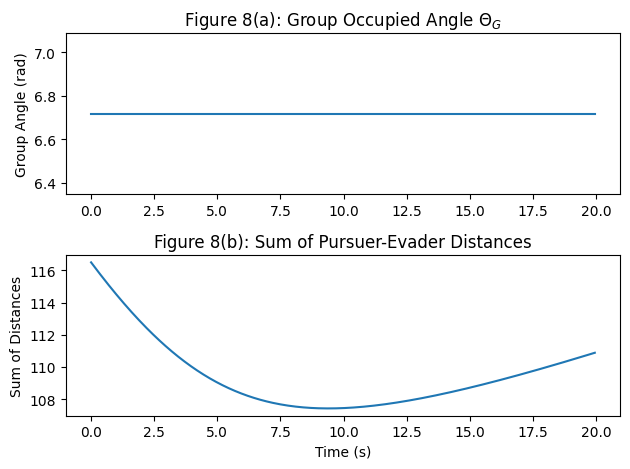

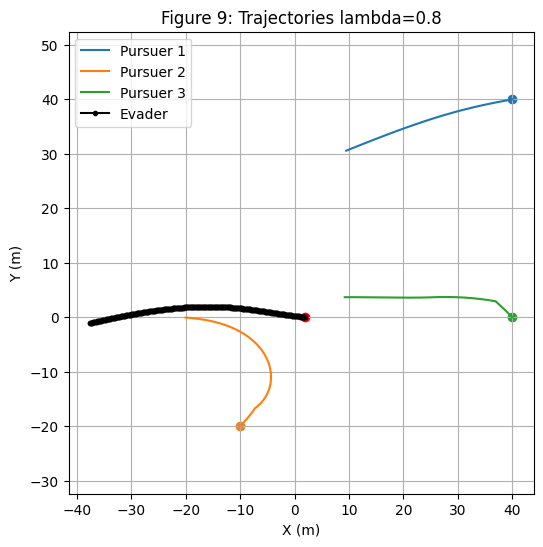

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ------ Problem Parameters ------
Ve = 2.0                      # Evader speed
lambdas = [0.9, 0.8]          # Pursuer/evader speed ratio for figs 7/8 and 9
Vp = [Ve * l for l in lambdas]
dc = 1.0                      # Capture radius
num_pursuers = 3
dt = 0.05                     # Smaller dt for precise encirclement shape
T = 20                        # Total duration (in seconds)
steps = int(T/dt)
ke = 140                      # Evader strategy parameter

# Initial positions: matches paper (p1, p2, p3, evader)
p_init = np.array([[40, 40], [-10, -20], [40, 0]])
evader_init = np.array([2, 0])

def local_polar(evader_pos, pursuers):
    rel = pursuers - evader_pos
    ri = np.linalg.norm(rel, axis=1)
    alpha = np.arctan2(rel[:,1], rel[:,0]) % (2 * np.pi)
    return ri, alpha

def neighbors(alpha):
    # Always sorted CCW, neighbors are cyclic (i-1, i+1)
    idx = np.argsort(alpha)
    nidx = []
    for k in range(len(alpha)):
        nidx.append(((idx[k-1]), (idx[(k+1)%len(alpha)])))
    # Reverse: for each original index, what neighbors exist?
    rev = np.zeros((len(alpha),2), dtype=int)
    for j in range(len(alpha)):
        i = idx[j]
        l, r = nidx[j]
        rev[i,0] = l
        rev[i,1] = r
    return rev

def occupied_angle(lam):
    # θi = 2 arcsin(λ)
    return 2*np.arcsin(lam)

def coverage_angle(alpha_i, alpha_j, theta_j, theta_i):
    # Eq (8): coverage angle e_{i,j}
    return (alpha_j - alpha_i - (theta_j + theta_i)/2 + 2*np.pi) % (2*np.pi)

def tradeoff_beta(eip1, eim1, ri):
    # See Eq (33)-(35): Only encirclement vs hunting trade-off, sin concave dependence
    delta = 2 * np.abs(eip1 - eim1) / (4*np.pi - 0) # (θi+1, θi-1 equal for equal V)
    gi = np.sin(np.pi * ri / (3*ri)) # 3 pursuers, symmetry
    beta = (np.pi/2)*(1 - np.exp(-delta * gi))
    return beta

def pursuers_control(evader_pos, pursuers, lambda_v, Vp):
    N = len(pursuers)
    ri, alpha = local_polar(evader_pos, pursuers)
    idx_neighbors = neighbors(alpha)
    theta_ = occupied_angle(lambda_v)

    # Sort alpha: CCW order for correct neighbor association
    purs = pursuers.copy()
    xi, yi = purs[:,0], purs[:,1]

    # Coverage angles for each pair, CCW
    eps = np.zeros(N)
    for i in range(N):
        idx_i = i
        idx_ip = idx_neighbors[i,1]
        idx_im = idx_neighbors[i,0]
        # Alpha: All [0,2π)
        ai, aip, aim = alpha[idx_i], alpha[idx_ip], alpha[idx_im]
        eps_ip = coverage_angle(ai, aip, theta_, theta_)
        eps_im = coverage_angle(aim, ai, theta_, theta_)

        # Trade-off
        beta = tradeoff_beta(eps_ip, eps_im, ri[i])

        # Surround and hunt magnitude (Eq. 27)
        ki = (Vp * np.sin(beta)) / (ri[i] * np.abs(eps_ip - eps_im)) if np.abs(eps_ip - eps_im) > 1e-6 else 1.0
        hi = (Vp * np.cos(beta)) / ri[i]

        # Hunt: towards evader in polar frame
        hunt = -hi*ri[i]*np.array([np.cos(alpha[i]), np.sin(alpha[i])])
        # Surround: perpendicular to hunt, direction determined by sign of eps_ip - eps_im
        dsign = 1 if eps_ip - eps_im >= 0 else -1
        surround = ki * ri[i] * (eps_ip - eps_im) * dsign * np.array([-np.sin(alpha[i]), np.cos(alpha[i])])

        v = hunt + surround
        # Normalize to max speed Vp
        speed = np.linalg.norm(v)
        if speed > 1e-8:
            v = Vp * v / speed
        else:
            v = np.zeros(2)
        yield v

def evader_strategy(pe, pursuers):
    ri = np.linalg.norm(pursuers - pe, axis=1, keepdims=True)
    direction = np.sum(ke * (pe - pursuers) / (ri+1e-6), axis=0) + pe
    v = direction / np.linalg.norm(direction)
    return Ve * v

def simulate(lambda_v, Vp, p_init, evader_init, plot_traj=True):
    pursuers = p_init.copy()
    pe = evader_init.copy()

    p_hist = [pursuers.copy()]
    e_hist = [pe.copy()]
    group_angle_list, dist_sum = [], []

    for t in range(steps):
        ri, alpha = local_polar(pe, pursuers)
        idx_neighbors = neighbors(alpha)
        theta = occupied_angle(lambda_v)
        epss = []
        # group occupied angle θG = sum θi + sum {overlap eps}
        for i in range(num_pursuers):
            idx_i = i
            idx_ip = idx_neighbors[i,1]
            eps_ip = coverage_angle(alpha[idx_i], alpha[idx_ip], theta, theta)
            epss.append(eps_ip)
        epss = np.array(epss)
        overlap_sum = np.sum(epss[epss <= 0]) # Only sum overlapping
        group_angle = num_pursuers * theta + overlap_sum
        group_angle_list.append(group_angle)
        dist_sum.append(np.sum(ri))

        # Pursuer velocities
        vs = np.array(list(pursuers_control(pe, pursuers, lambda_v, Vp)))
        pursuers = pursuers + dt * vs

        # Evader velocity
        ve = evader_strategy(pe, pursuers)
        pe = pe + dt * ve

        p_hist.append(pursuers.copy())
        e_hist.append(pe.copy())

        # Capture condition
        if np.any(np.linalg.norm(pursuers - pe, axis=1) < dc):
            break

    p_hist = np.array(p_hist)
    e_hist = np.array(e_hist)
    return p_hist, e_hist, np.array(group_angle_list), np.array(dist_sum)

# -------- Simulations for figs 7/8/9 --------
# Figure 7/8: lambda=0.9, Figure 9: lambda=0.8

for i, (lmb, Vpp) in enumerate(zip(lambdas, Vp)):
    runname = f"lambda={lmb}"
    p_hist, e_hist, group_angle, dist_sum = simulate(lmb, Vpp, p_init, evader_init)

    # Trajectory plot
    plt.figure(figsize=(6,6))
    for k in range(num_pursuers):
        plt.plot(p_hist[:,k,0], p_hist[:,k,1], label=f'Pursuer {k+1}')
        plt.scatter(p_init[k,0], p_init[k,1], marker='o', color=f'C{k}')
    plt.plot(e_hist[:,0], e_hist[:,1], '-ko', label='Evader', markersize=3)
    plt.scatter(evader_init[0], evader_init[1], c='red')
    plt.xlabel("X (m)"); plt.ylabel("Y (m)");
    plt.title(f"Figure {7+i if lmb==0.9 else 9}: Trajectories {runname}")
    plt.legend(); plt.grid(True); plt.axis("equal")
    plt.show()

    if lmb == 0.9:
        # Figure 8 (only for lambda=0.9)
        plt.figure()
        plt.subplot(211)
        plt.plot(np.arange(len(group_angle))*dt, group_angle)
        plt.ylabel("Group Angle (rad)")
        plt.title(r"Figure 8(a): Group Occupied Angle $\Theta_G$")
        plt.subplot(212)
        plt.plot(np.arange(len(dist_sum))*dt, dist_sum)
        plt.ylabel("Sum of Distances")
        plt.xlabel("Time (s)")
        plt.title("Figure 8(b): Sum of Pursuer-Evader Distances")
        plt.tight_layout()
        plt.show()
